# CS6444 Project 1 - R and Graph Analytics
## Stanford Web Graph (2002)

### Team
- Fatulla Bashirov
- Kamal Ahmadov

### Dataset
This notebook uses the Stanford Web Graph dataset (`web-Stanford.txt`).
- Each vertex is a Stanford webpage.
- Each directed edge is a hyperlink from one page to another page.

### Business / social problem
This network models information flow inside a large academic domain. Graph analytics helps identify:
- highly influential pages,
- local clusters of related pages,
- bridge pages that connect regions,
- and structural properties that impact discoverability.


## 0. Setup
This section loads required packages and sets reproducibility options.

In [1]:
required_packages <- c("igraph", "data.table")
missing_packages <- required_packages[!sapply(required_packages, requireNamespace, quietly = TRUE)]
if (length(missing_packages) > 0) {
  install.packages(missing_packages, repos = "https://cloud.r-project.org")
}

library(igraph)
library(data.table)

options(width = 120)
set.seed(6444)



Attaching package: 'igraph'




The following objects are masked from 'package:stats':

    decompose, spectrum




The following object is masked from 'package:base':

    union




## 1. Load Dataset and Describe the Raw Data
The assignment requires at least 50,000 vertices. The Stanford graph exceeds this requirement by a large margin.

The code below first resolves a path that works both locally and on Kaggle.

In [2]:
candidate_paths <- c(
  "./data/web-Stanford.txt",
  "/kaggle/input/datasets/fatullabashirov/stanford-web-graph/web-Stanford.txt"
)
file_path <- candidate_paths[file.exists(candidate_paths)][1]
if (is.na(file_path)) {
  stop("Dataset file not found. Place web-Stanford.txt in ./data or update the Kaggle path.")
}

edges <- fread(
  file_path,
  sep = "\t",
  header = FALSE,
  comment.char = "#",
  col.names = c("from", "to")
)

cat("Using file:", file_path, "\n")
cat("Raw edge-list rows:", nrow(edges), "\n")
cat("Columns:", ncol(edges), "\n")
head(edges)
summary(edges)


Using file: ./data/web-Stanford.txt 


Raw edge-list rows: 2312497 


Columns: 2 


from,to
<int>,<int>
1,6548
1,15409
6548,57031
15409,13102
2,17794
2,25202


      from              to        
 Min.   :     1   Min.   :     2  
 1st Qu.: 70779   1st Qu.: 73100  
 Median :141051   Median :143725  
 Mean   :140961   Mean   :143950  
 3rd Qu.:211225   3rd Qu.:218070  
 Max.   :281903   Max.   :281903  

## 2. Build the Initial Directed Graph and Report Required Properties
Required metrics from item #1 are computed here:
- number of nodes,
- number of edges,
- sparsity,
- directedness,
- node/edge property examples.

There are no native node attributes in the raw file except page IDs, so we treat degree-based statistics as node properties.

In [3]:
g <- graph_from_data_frame(edges, directed = TRUE)

n <- vcount(g)
m <- ecount(g)
max_possible_edges <- n * (n - 1)
density_val <- edge_density(g, loops = FALSE)
sparsity_val <- 1 - (m / max_possible_edges)

cat("Vertices:", n, "\n")
cat("Edges:", m, "\n")
cat("Directed (arrowness):", is_directed(g), "\n")
cat("Has loops:", any_loop(g), "\n")
cat("Density:", density_val, "\n")
cat("Sparsity:", sparsity_val, "\n")

# Node-property examples from structure
in_deg <- degree(g, mode = "in")
out_deg <- degree(g, mode = "out")
all_deg <- degree(g, mode = "all")

cat("\nIn-degree summary:\n")
print(summary(in_deg))
cat("\nOut-degree summary:\n")
print(summary(out_deg))
cat("\nTotal-degree summary:\n")
print(summary(all_deg))

# Edge-property example: reciprocity at graph level and edge count by endpoint degree class
weak_comp <- components(as_undirected(g, mode = "collapse"))
strong_comp <- components(g, mode = "strong")
cat("\nWeakly connected components:", weak_comp$no, "\n")
cat("Largest WCC size:", max(weak_comp$csize), "\n")
cat("Strongly connected components:", strong_comp$no, "\n")
cat("Largest SCC size:", max(strong_comp$csize), "\n")


Vertices: 281903 


Edges: 2312497 


Directed (arrowness): TRUE 


Has loops: FALSE 


Density: 2.909935e-05 


...

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
    1.00     5.00     8.00    16.41    12.00 38626.00 



Weakly connected components: 365 


Largest WCC size: 255265 


Strongly connected components: 29914 


Largest SCC size: 150532 


### Figure 1. Initial Visualization Baseline
A small induced sample from the original graph is plotted to show that direct visualization of the full network is not interpretable.

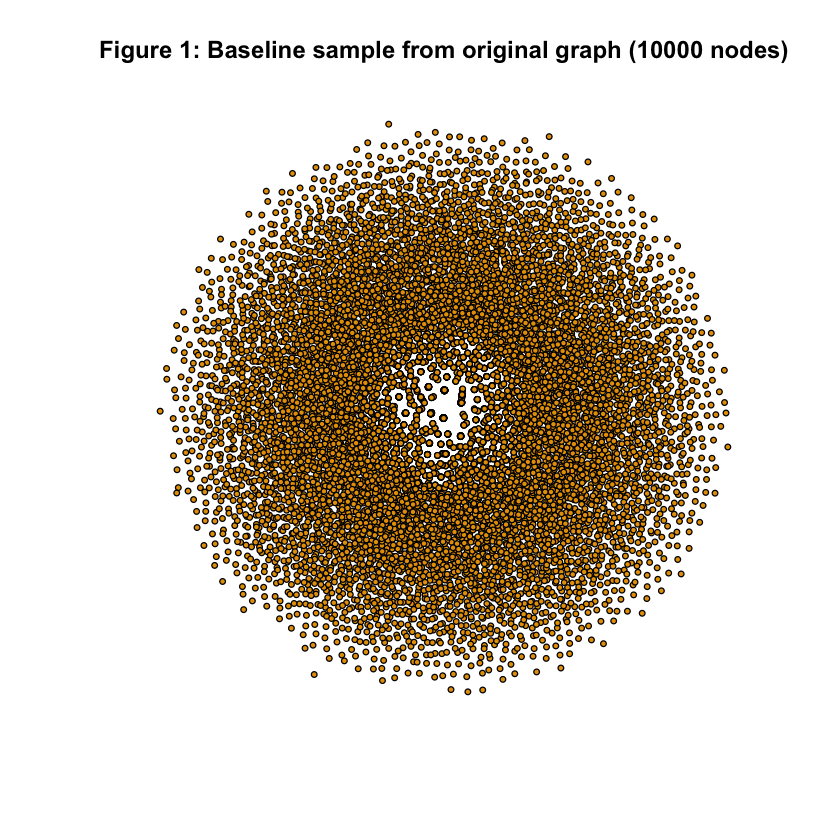

In [4]:
sample_size <- min(10000, vcount(g))
sample_nodes <- sample(V(g), sample_size)
g_sample_original <- induced_subgraph(g, sample_nodes)

plot(
  g_sample_original,
  vertex.size = 2,
  vertex.label = NA,
  edge.arrow.size = 0.05,
  main = sprintf("Figure 1: Baseline sample from original graph (%d nodes)", vcount(g_sample_original))
)


## 3. Graph Simplification Strategy
Because the original network is too large for expensive analytics, we simplify in multiple steps:
1. `simplify()` to remove loops and duplicate edges.
2. Keep only the largest weakly connected component.
3. Degree filtering (keep high-signal pages with total degree above the 97th percentile).
4. Keep top PageRank vertices for advanced analytics.

This goes beyond only using `simplify()` as required by the assignment.

In [5]:
g_simple <- simplify(g, remove.multiple = TRUE, remove.loops = TRUE)

comp_simple <- components(as_undirected(g_simple, mode = "collapse"))
giant_id <- which.max(comp_simple$csize)
g_giant <- induced_subgraph(g_simple, V(g_simple)[comp_simple$membership == giant_id])

giant_deg <- degree(g_giant, mode = "all")
deg_cutoff <- as.numeric(quantile(giant_deg, 0.97))
g_degree_filtered <- induced_subgraph(g_giant, V(g_giant)[giant_deg >= deg_cutoff])

pr_filtered <- page_rank(g_degree_filtered, directed = TRUE)$vector
analysis_n <- min(450, length(pr_filtered))
analysis_vertices <- names(sort(pr_filtered, decreasing = TRUE))[1:analysis_n]
g_analysis <- induced_subgraph(g_degree_filtered, vids = analysis_vertices)

g_analysis_u <- as_undirected(g_analysis, mode = "collapse")

# Assign edge weights based on endpoint total degree (structural importance proxy)
analysis_deg <- degree(g_analysis, mode = "all")
edge_ends <- ends(g_analysis, E(g_analysis), names = TRUE)
E(g_analysis)$weight <- (analysis_deg[edge_ends[, 1]] + analysis_deg[edge_ends[, 2]]) / 2

cat("Simplification summary:\n")
cat("Original graph:", vcount(g), "nodes,", ecount(g), "edges\n")
cat("After simplify():", vcount(g_simple), "nodes,", ecount(g_simple), "edges\n")
cat("Largest WCC:", vcount(g_giant), "nodes,", ecount(g_giant), "edges\n")
cat("After degree filter (>= 97th percentile):", vcount(g_degree_filtered), "nodes,", ecount(g_degree_filtered), "edges\n")
cat("Analysis graph (top PageRank):", vcount(g_analysis), "nodes,", ecount(g_analysis), "edges\n")


Simplification summary:


Original graph: 281903 nodes, 2312497 edges


After simplify(): 281903 nodes, 2312497 edges


Largest WCC: 255265 nodes, 2234572 edges


After degree filter (>= 97th percentile): 7761 nodes, 189062 edges


Analysis graph (top PageRank): 450 nodes, 6909 edges


## 4. Explore 10+ Additional `igraph` Functions (Not Used in Tutorial)
The following section demonstrates functions that are not listed in `used_in_tutorial.md`.

Functions demonstrated:
1. `is_connected()`
2. `page_rank()`
3. `eigen_centrality()`
4. `strength()`
5. `articulation_points()`
6. `bridges()`
7. `dyad_census()`
8. `triad_census()`
9. `similarity()` with Jaccard method
10. `eccentricity()`
11. `cluster_walktrap()`


In [6]:
# 1) Connectivity check on the analysis graph (undirected view)
connected_flag <- is_connected(g_analysis_u)

# 2) PageRank centrality
pr <- page_rank(g_analysis, directed = TRUE)$vector

# 3) Eigenvector centrality
eig <- eigen_centrality(g_analysis_u, directed = FALSE)$vector

# 4) Weighted strength using the synthetic weight attribute
str_w <- strength(g_analysis, mode = "all", weights = E(g_analysis)$weight)

# 5) Articulation points (critical nodes for connectivity)
ap <- articulation_points(g_analysis_u)

# 6) Bridges (critical edges)
br <- bridges(g_analysis_u)

# 7) Dyad census (directed pair categories)
dyad <- dyad_census(g_analysis)

# 8) Triad census can be expensive; compute on smaller directed sample
triad_sample_n <- min(120, vcount(g_analysis))
triad_nodes <- V(g_analysis)[1:triad_sample_n]
g_triad <- induced_subgraph(g_analysis, triad_nodes)
triad <- triad_census(g_triad)

# 9) Jaccard similarity for top 10 PageRank nodes
top10 <- names(sort(pr, decreasing = TRUE))[1:min(10, length(pr))]
jacc <- similarity(g_analysis_u, vids = V(g_analysis_u)[top10], method = "jaccard")

# 10) Eccentricity on undirected analysis graph
ecc <- eccentricity(g_analysis_u)

# 11) Community detection with walktrap
wt <- cluster_walktrap(g_analysis_u)

cat("is_connected():", connected_flag, "\n")
cat("page_rank() top node:", names(which.max(pr)), "score:", max(pr), "\n")
cat("eigen_centrality() top node:", names(which.max(eig)), "score:", max(eig), "\n")
cat("strength() summary:\n")
print(summary(str_w))
cat("articulation_points() count:", length(ap), "\n")
cat("bridges() count:", length(br), "\n")
cat("dyad_census():", paste(names(dyad), dyad, collapse = "; "), "\n")
cat("triad_census() non-zero classes:\n")
print(triad[triad > 0])
cat("eccentricity() summary:\n")
print(summary(ecc))
cat("cluster_walktrap(): communities =", length(sizes(wt)), ", modularity =", modularity(wt), "\n")
cat("Jaccard similarity matrix (top10 PageRank nodes):\n")
print(round(jacc, 3))


is_connected(): FALSE 


page_rank() top node: 226411 score: 0.04068704 


eigen_centrality() top node: 53608 score: 1 


strength() summary:


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    0.0   199.6   460.2  1736.0  1232.5 12403.0 


...

eccentricity() summary:


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   4.000   5.000   4.469   6.000   7.000 


cluster_walktrap(): communities = 46 , modularity = 0.7318534 


Jaccard similarity matrix (top10 PageRank nodes):


       [,1]  [,2]  [,3]  [,4]  [,5]  [,6]  [,7]  [,8]  [,9] [,10]
 [1,] 1.000 0.120 0.121 0.111 0.113 0.108 0.114 0.107 0.107 0.108
 [2,] 0.120 1.000 0.710 0.647 0.688 0.786 0.793 0.759 0.759 0.786
 [3,] 0.121 0.710 1.000 0.667 0.710 0.815 0.759 0.786 0.786 0.815
 [4,] 0.111 0.647 0.667 1.000 0.647 0.733 0.688 0.710 0.710 0.733
 [5,] 0.113 0.688 0.710 0.647 1.000 0.786 0.733 0.759 0.759 0.786
 [6,] 0.108 0.786 0.815 0.733 0.786 1.000 0.846 0.880 0.880 0.917
 [7,] 0.114 0.793 0.759 0.688 0.733 0.846 1.000 0.815 0.815 0.846
 [8,] 0.107 0.759 0.786 0.710 0.759 0.880 0.815 1.000 0.846 0.880
 [9,] 0.107 0.759 0.786 0.710 0.759 0.880 0.815 0.846 1.000 0.880
[10,] 0.108 0.786 0.815 0.733 0.786 0.917 0.846 0.880 0.880 1.000


## 5. Required Graph Analysis Tasks

In [7]:
# (a) Central nodes: use PageRank and eigenvector centrality
central_table <- data.frame(
  vertex = V(g_analysis)$name,
  pagerank = pr[V(g_analysis)$name],
  eigen = eig[V(g_analysis)$name],
  strength = str_w[V(g_analysis)$name]
)
central_table <- central_table[order(-central_table$pagerank), ]

cat("(a) Top 10 central nodes by PageRank:\n")
print(head(central_table, 10))


(a) Top 10 central nodes by PageRank:


       vertex   pagerank       eigen strength
226411 226411 0.04068704 0.043083227  12403.0
145892 145892 0.01523340 0.001597563   1398.0
60440   60440 0.01483982 0.001628194   1335.0
208542 208542 0.01443514 0.001581821   1329.0
112742 112742 0.01414866 0.001580707   1247.5
161890 161890 0.01397844 0.001560232   1230.5
151428 151428 0.01375307 0.001585447   1187.0
222873 222873 0.01371764 0.001561323   1171.5
91         91 0.01345771 0.001561571   1119.0
96358   96358 0.01300006 0.001560232   1045.5


In [8]:
# (b) Longest path approximation via graph diameter path (largest geodesic path)
diam_vertices <- get_diameter(g_analysis_u, directed = FALSE)
diam_names <- V(g_analysis_u)[diam_vertices]$name

diam_len <- diameter(g_analysis_u, directed = FALSE, unconnected = TRUE)
cat("(b) Diameter path length (edges):", diam_len, "\n")
cat("Diameter path vertices:\n")
print(diam_names)


(b) Diameter path length (edges): 7 


Diameter path vertices:


[1] "273998" "267959" "84906"  "226411" "112742" "7621"   "3627"   "45925" 


In [9]:
# (c) Largest cliques (computed on undirected graph)
# Clique search can become expensive; analysis graph size was controlled earlier.
lc <- largest_cliques(g_analysis_u)
max_clique_size <- if (length(lc) > 0) length(lc[[1]]) else 0

cat("(c) Number of largest cliques found:", length(lc), "\n")
cat("Largest clique size:", max_clique_size, "\n")
if (length(lc) > 0) {
  cat("Example largest clique (vertex IDs):\n")
  print(V(g_analysis_u)[lc[[1]]]$name)
}


(c) Number of largest cliques found: 2 


Largest clique size: 50 


Example largest clique (vertex IDs):
 [1] "44707"  "267959" "21613"  "11845"  "19140"  "65051"  "46399"  "60729"  "59550"  "100221" "116934" "110793"
[13] "107314" "138757" "173778" "150384" "145726" "171676" "168644" "157682" "204711" "183244" "201128" "225954"
[25] "233888" "225390" "230911" "69244"  "15240"  "53608"  "66825"  "51628"  "52223"  "63718"  "73530"  "86939" 
[37] "105147" "133715" "190375" "219188" "212707" "235570" "259439" "252121" "268779" "101858" "134159" "151707"
[49] "3164"   "84906" 


In [10]:
# (d) Ego networks around top PageRank node
top_node <- central_table$vertex[1]
ego_graphs <- make_ego_graph(g_analysis_u, order = 2, nodes = V(g_analysis_u)[top_node], mode = "all")
ego_top <- ego_graphs[[1]]

cat("(d) Ego network around top central node:", top_node, "\n")
cat("Ego nodes (order=2):", vcount(ego_top), "\n")
cat("Ego edges (order=2):", ecount(ego_top), "\n")


(d) Ego network around top central node: 226411 


Ego nodes (order=2): 309 


Ego edges (order=2): 3618 


In [11]:
# (e) Power centrality
pow <- NULL
pow_exp <- NA
for (ex in c(0.25, 0.10, 0.05, 0.01)) {
  candidate <- tryCatch(
    power_centrality(g_analysis_u, exponent = ex),
    error = function(e) NULL
  )
  if (!is.null(candidate)) {
    pow <- candidate
    pow_exp <- ex
    break
  }
}
if (is.null(pow)) {
  stop("Power centrality failed for all tested exponents.")
}

pow_sorted <- sort(pow, decreasing = TRUE)
cat("(e) Power centrality exponent used:", pow_exp, "\n")
cat("(e) Top 10 power-central nodes:\n")
print(head(pow_sorted, 10))


(e) Power centrality exponent used: 0.05 


(e) Top 10 power-central nodes:


  208542   145892   112742    60440       91   222873   161890    96358   151428   118244 
2.876078 2.859514 2.850633 2.785577 2.760024 2.750756 2.732615 2.732615 2.608838 2.475662 


In [12]:
# (f) Communities using walktrap
community_sizes <- sizes(wt)

cat("(f) Communities (walktrap):", length(community_sizes), "\n")
cat("Community size summary:\n")
print(summary(as.numeric(community_sizes)))
cat("Modularity:", modularity(wt), "\n")


(f) Communities (walktrap): 46 


Community size summary:


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   2.000   6.000   9.783  11.000  60.000 


Modularity: 0.7318534 


## 6. Visualization on 30-100 Vertices
To produce interpretable visuals, we build a focused subgraph with up to 80 vertices.

Visual encodings:
- Vertex color: community membership
- Vertex size: normalized PageRank
- Vertex shape: top-10 PageRank (`square`) vs others (`circle`)
- Edge width/color: weight intensity
- Edge type: intra-community (`solid`) vs inter-community (`dashed`)


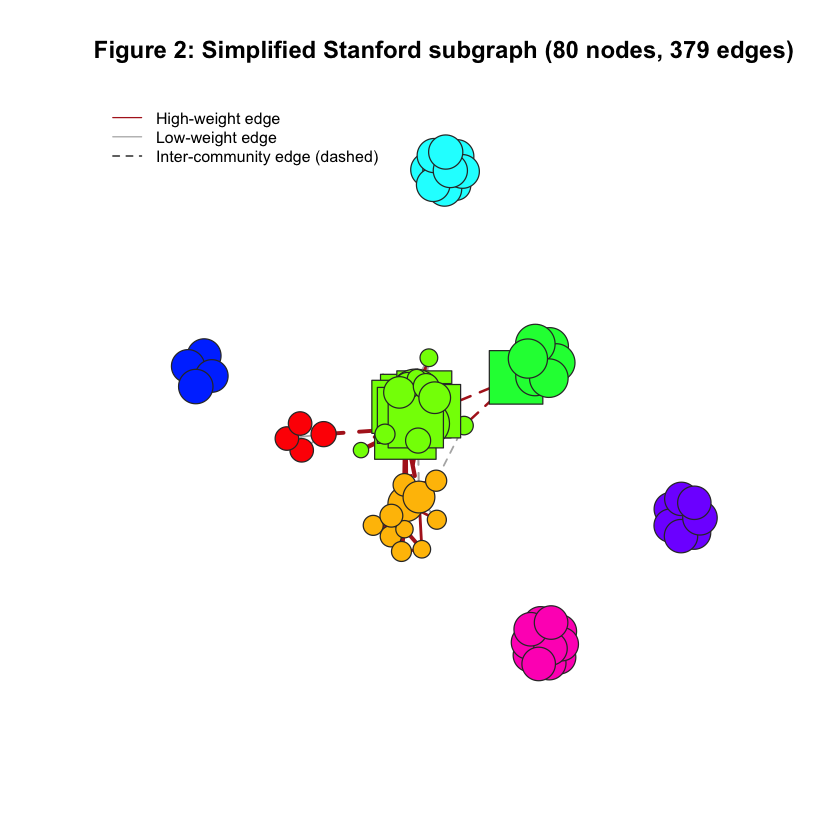

In [13]:
viz_n <- min(80, nrow(central_table))
viz_nodes <- central_table$vertex[1:viz_n]
g_viz <- induced_subgraph(g_analysis, vids = V(g_analysis)[viz_nodes])
g_viz_u <- as_undirected(g_viz, mode = "collapse")

# Recompute walktrap on visualization graph for stable community labels
viz_comm <- cluster_walktrap(g_viz_u)
member <- membership(viz_comm)

# Vertex aesthetics
pal <- rainbow(length(unique(member)))
V(g_viz_u)$color <- pal[member]

pr_viz <- page_rank(g_viz, directed = TRUE)$vector
pr_scaled <- 6 + 18 * (pr_viz - min(pr_viz)) / (max(pr_viz) - min(pr_viz) + 1e-9)
V(g_viz_u)$size <- pr_scaled[V(g_viz_u)$name]

top10_viz <- names(sort(pr_viz, decreasing = TRUE))[1:min(10, length(pr_viz))]
V(g_viz_u)$shape <- ifelse(V(g_viz_u)$name %in% top10_viz, "square", "circle")
V(g_viz_u)$label <- NA

# Edge aesthetics
if (is.null(E(g_viz)$weight)) {
  E(g_viz)$weight <- 1
}
edge_ends_viz <- ends(g_viz, E(g_viz), names = TRUE)
edge_weight_lookup <- E(g_viz)$weight

# Map weights to undirected edges by averaging directed duplicates
E(g_viz_u)$weight <- 1
for (i in seq_len(ecount(g_viz_u))) {
  e <- ends(g_viz_u, E(g_viz_u)[i], names = TRUE)
  idx <- which((edge_ends_viz[,1] == e[1] & edge_ends_viz[,2] == e[2]) |
               (edge_ends_viz[,1] == e[2] & edge_ends_viz[,2] == e[1]))
  if (length(idx) > 0) {
    E(g_viz_u)$weight[i] <- mean(edge_weight_lookup[idx])
  }
}

w <- E(g_viz_u)$weight
w_scaled <- 1 + 3 * (w - min(w)) / (max(w) - min(w) + 1e-9)
E(g_viz_u)$width <- w_scaled
E(g_viz_u)$color <- ifelse(w >= median(w), "firebrick", "gray70")

edge_ends_u <- ends(g_viz_u, E(g_viz_u), names = FALSE)
E(g_viz_u)$lty <- ifelse(member[edge_ends_u[,1]] == member[edge_ends_u[,2]], 1, 2)

layout_viz <- layout_with_graphopt(g_viz_u)

plot(
  g_viz_u,
  layout = layout_viz,
  vertex.frame.color = "gray20",
  main = sprintf("Figure 2: Simplified Stanford subgraph (%d nodes, %d edges)", vcount(g_viz_u), ecount(g_viz_u))
)
legend(
  "topleft",
  legend = c("High-weight edge", "Low-weight edge", "Inter-community edge (dashed)"),
  col = c("firebrick", "gray70", "black"),
  lty = c(1, 1, 2),
  bty = "n",
  cex = 0.8
)


## 7. Listing of R / igraph Functions Used
The assignment requests a list of functions used. The list below includes key functions used in this notebook.

In [14]:
functions_used <- c(
  # Data loading / prep
  "fread", "graph_from_data_frame", "as_undirected", "induced_subgraph", "simplify",
  # Basic graph stats
  "vcount", "ecount", "edge_density", "components", "degree", "any_loop", "is_directed",
  # Item #4 (non-tutorial list)
  "is_connected", "page_rank", "eigen_centrality", "strength", "articulation_points", "bridges",
  "dyad_census", "triad_census", "similarity", "eccentricity", "cluster_walktrap",
  # Item #5 required analysis
  "get_diameter", "diameter", "largest_cliques", "make_ego_graph", "power_centrality",
  "membership", "sizes", "modularity",
  # Visualization
  "layout_with_graphopt", "plot", "legend", "ends", "E", "V"
)

cat("Total functions listed:", length(unique(functions_used)), "\n")
print(sort(unique(functions_used)))


Total functions listed: 37 


 [1] "any_loop"              "articulation_points"   "as_undirected"         "bridges"              
 [5] "cluster_walktrap"      "components"            "degree"                "diameter"             
 [9] "dyad_census"           "E"                     "eccentricity"          "ecount"               
[13] "edge_density"          "eigen_centrality"      "ends"                  "fread"                
[17] "get_diameter"          "graph_from_data_frame" "induced_subgraph"      "is_connected"         
[21] "is_directed"           "largest_cliques"       "layout_with_graphopt"  "legend"               
[25] "make_ego_graph"        "membership"            "modularity"            "page_rank"            
[29] "plot"                  "power_centrality"      "similarity"            "simplify"             
[33] "sizes"                 "strength"              "triad_census"          "V"                    
[37] "vcount"               


## 8. Insights and Interpretation
1. **Scale and sparsity**: The Stanford web graph is very sparse relative to all possible directed links.
2. **Centralization**: Centrality distributions are highly skewed; a small set of pages dominates influence/visibility.
3. **Critical structure**: Articulation points and bridge edges indicate fragile connectors between subregions.
4. **Communities**: Walktrap detects modular sub-structures, suggesting topical or organizational clustering.
5. **Practical simplification**: Multi-step simplification (not only `simplify()`) is necessary to make high-cost analytics and visualization feasible.

### Problems encountered and how they were solved
- **Problem**: Full graph plotting is unreadable.
- **Solution**: Build focused subgraphs (degree + PageRank filtering), then produce 30-100 node visualization.

- **Problem**: Some analytics (triad/clique) become expensive on large graphs.
- **Solution**: Use a controlled analysis graph size and a smaller sample for triad census.


In [15]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: aarch64-apple-darwin20
Running under: macOS Sequoia 15.3.2

Matrix products: default
BLAS:   /System/Library/Frameworks/Accelerate.framework/Versions/A/Frameworks/vecLib.framework/Versions/A/libBLAS.dylib 
LAPACK: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRlapack.dylib;  LAPACK version 3.12.1

locale:
[1] C.UTF-8/C/C.UTF-8/C/C.UTF-8/C.UTF-8

time zone: Asia/Baku
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] data.table_1.18.2.1 igraph_2.2.2       

loaded via a namespace (and not attached):
 [1] digest_0.6.39   IRdisplay_1.1   base64enc_0.1-6 fastmap_1.2.0   Matrix_1.7-4    lattice_0.22-7  magrittr_2.0.4 
 [8] glue_1.8.0      pkgconfig_2.0.3 htmltools_0.5.9 repr_1.1.7      lifecycle_1.0.5 cli_3.6.5       grid_4.5.2     
[15] vctrs_0.7.1     pbdZMQ_0.3-14   compiler_4.5.2  tools_4.5.2     evaluate_1.0.5  pillar_1.11.1 